TP : Détection de Fraude Bancaire - Machine Learning vs Deep Learning

Objectifs du TP :
Comprendre la différence entre ML classique et Deep Learning
Gérer un dataset extrêmement déséquilibré
Créer des interfaces interactives avec Gradio
Comparer les performances des deux approches

Partie 1 : Configuration et Import des bibliothèques

In [1]:
%pip install matplotlib seaborn gradio scikit-learn xgboost imbalanced-learn tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import gradio as gr
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pour le ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# Pour le DL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

print("Bibliothèques importées avec succès!")
print(f"TensorFlow version: {tf.__version__}")

Note: you may need to restart the kernel to use updated packages.


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliothèques importées avec succès!
TensorFlow version: 2.21.0


Partie 2 : Chargement et Exploration des données

In [2]:
# Chargement des données
df = pd.read_csv('creditcard.csv')
print(f"Shape du dataset: {df.shape}")
print(f"\nColonnes: {df.columns.tolist()}")
print(f"\nTypes de données:\n{df.dtypes}")

Shape du dataset: (284807, 31)

Colonnes: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Types de données:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


Partie 3 : Prétraitement des données

In [3]:
# @title 3. Préparation des données
# Séparation features/target
X = df.drop('Class', axis=1)
y = df['Class']

# Normalisation des features 'Time' et 'Amount'
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille train: {X_train.shape}")
print(f"Taille test: {X_test.shape}")
print(f"Distribution train:\n{y_train.value_counts()}")
print(f"Distribution test:\n{y_test.value_counts()}")

# Application de SMOTE pour équilibrer les classes (pour l'entraînement ML)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"\nAprès SMOTE - Taille train: {X_train_smote.shape}")
print(f"Distribution après SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

Taille train: (227845, 30)
Taille test: (56962, 30)
Distribution train:
Class
0    227451
1       394
Name: count, dtype: int64
Distribution test:
Class
0    56864
1       98
Name: count, dtype: int64

Après SMOTE - Taille train: (454902, 30)
Distribution après SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


Partie 4 : Approche Machine Learning

In [4]:
# @title 5. Modèles Machine Learning
print("="*50)
print("ENTRAÎNEMENT DES MODÈLES MACHINE LEARNING")
print("="*50)

# Dictionnaire pour stocker les modèles et leurs performances
ml_models = {}
ml_predictions = {}

# 1. Régression Logistique
print("\n1. Entraînement de la Régression Logistique...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
ml_models['Logistic Regression'] = lr
ml_predictions['Logistic Regression'] = lr.predict(X_test)
print("✓ Terminé")

# 2. Random Forest
print("\n2. Entraînement du Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
ml_models['Random Forest'] = rf
ml_predictions['Random Forest'] = rf.predict(X_test)
print("✓ Terminé")

# 3. XGBoost
print("\n3. Entraînement du XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)
ml_models['XGBoost'] = xgb
ml_predictions['XGBoost'] = xgb.predict(X_test)
print("✓ Terminé")

ENTRAÎNEMENT DES MODÈLES MACHINE LEARNING

1. Entraînement de la Régression Logistique...
✓ Terminé

2. Entraînement du Random Forest...
✓ Terminé

3. Entraînement du XGBoost...
✓ Terminé



ÉVALUATION: Logistic Regression

Rapport de Classification:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9698


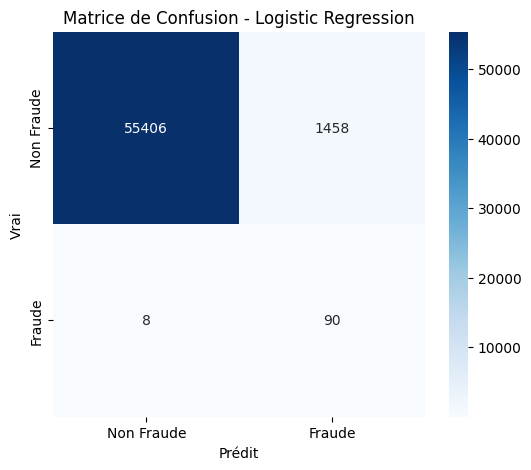


ÉVALUATION: Random Forest

Rapport de Classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9731


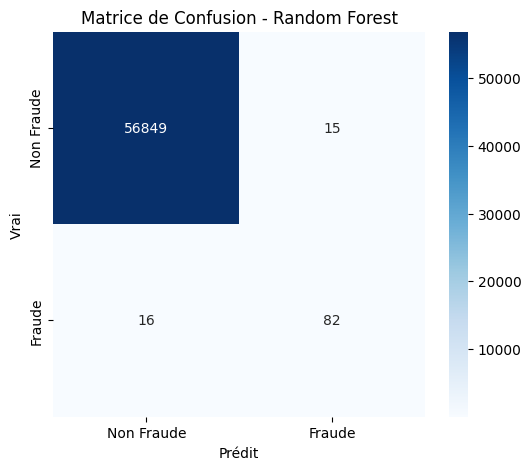


ÉVALUATION: XGBoost

Rapport de Classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9792


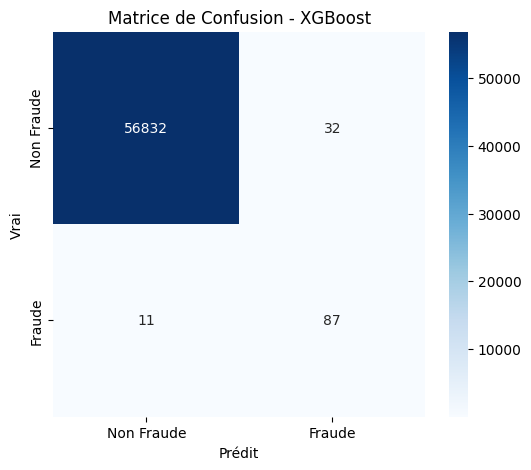

In [5]:
# @title 6. Évaluation des modèles ML
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f"\n{'='*40}")
    print(f"ÉVALUATION: {name}")
    print('='*40)
    
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    
    # Rapport de classification
    print("\nRapport de Classification:")
    print(classification_report(y_true, y_pred))
    
    # Score ROC-AUC si probabilités disponibles
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC Score: {roc_auc:.4f}")
    
    # Visualisation de la matrice de confusion
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non Fraude', 'Fraude'],
                yticklabels=['Non Fraude', 'Fraude'])
    plt.title(f'Matrice de Confusion - {name}')
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.show()
    
    return {
        'name': name,
        'confusion_matrix': cm,
        'report': classification_report(y_true, y_pred, output_dict=True)
    }

# Évaluation de chaque modèle
ml_results = []

for name, model in ml_models.items():
    y_pred = ml_predictions[name]
    # Obtenir les probabilités si disponibles
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    result = evaluate_model(name, y_test, y_pred, y_proba)
    ml_results.append(result)

Partie 5 : Approche Deep Learning

In [6]:
# @title 7. Création du modèle Deep Learning
print("="*50)
print("CRÉATION DU MODÈLE DEEP LEARNING")
print("="*50)

def create_dl_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Première couche cachée
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Deuxième couche cachée
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Troisième couche cachée
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        # Couche de sortie
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Création du modèle
dl_model = create_dl_model(X_train_smote.shape[1])
dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

print("\nArchitecture du modèle Deep Learning:")
dl_model.summary()

CRÉATION DU MODÈLE DEEP LEARNING

Architecture du modèle Deep Learning:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
# @title 8. Entraînement du modèle Deep Learning
print("="*50)
print("ENTRAÎNEMENT DU MODÈLE DEEP LEARNING")
print("="*50)

# Callbacks pour améliorer l'entraînement
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# Entraînement
history = dl_model.fit(
    X_train_smote, y_train_smote,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Entraînement terminé!")

ENTRAÎNEMENT DU MODÈLE DEEP LEARNING
Epoch 1/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9757 - auc: 0.9970 - loss: 0.0653 - precision: 0.9705 - recall: 0.9645 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0037 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9941 - auc: 0.9995 - loss: 0.0182 - precision: 0.9905 - recall: 0.9938 - val_accuracy: 0.9985 - val_auc: 0.0000e+00 - val_loss: 0.0048 - val_precision: 1.0000 - val_recall: 0.9985 - learning_rate: 0.0010
Epoch 3/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9967 - auc: 0.9997 - loss: 0.0114 - precision: 0.9942 - recall: 0.9969 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0011 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9977 - auc: 0.9997 - loss: 0.0084 - precision: 0.9958 - recall: 0.9979 

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step

ÉVALUATION: Deep Learning

Rapport de Classification:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.82      0.77        98

    accuracy                           1.00     56962
   macro avg       0.86      0.91      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9554


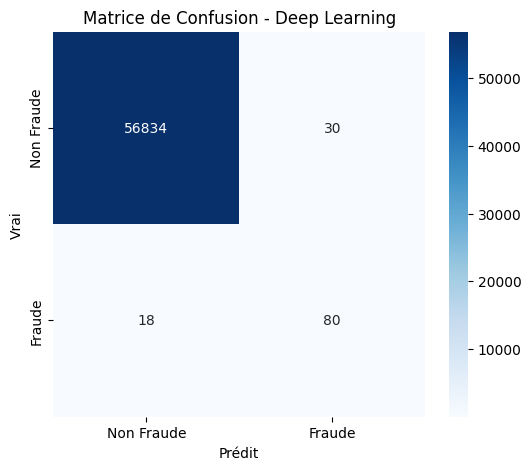

In [10]:
# @title 8. Évaluation du modèle Deep Learning
# Prédictions
y_pred_dl_proba = dl_model.predict(X_test)
y_pred_dl = (y_pred_dl_proba > 0.5).astype(int)

# Évaluation
dl_result = evaluate_model('Deep Learning', y_test, y_pred_dl, y_pred_dl_proba)

Partie 6 : Comparaison des approches

COMPARAISON ML VS DEEP LEARNING

Tableau comparatif:
             Modèle             Type  Précision (Fraude)  Rappel (Fraude)  F1-Score (Fraude)  Accuracy
Logistic Regression Machine Learning            0.058140         0.918367           0.109356  0.974264
      Random Forest Machine Learning            0.845361         0.836735           0.841026  0.999456
            XGBoost Machine Learning            0.731092         0.887755           0.801843  0.999245
      Deep Learning    Deep Learning            0.727273         0.816327           0.769231  0.999157


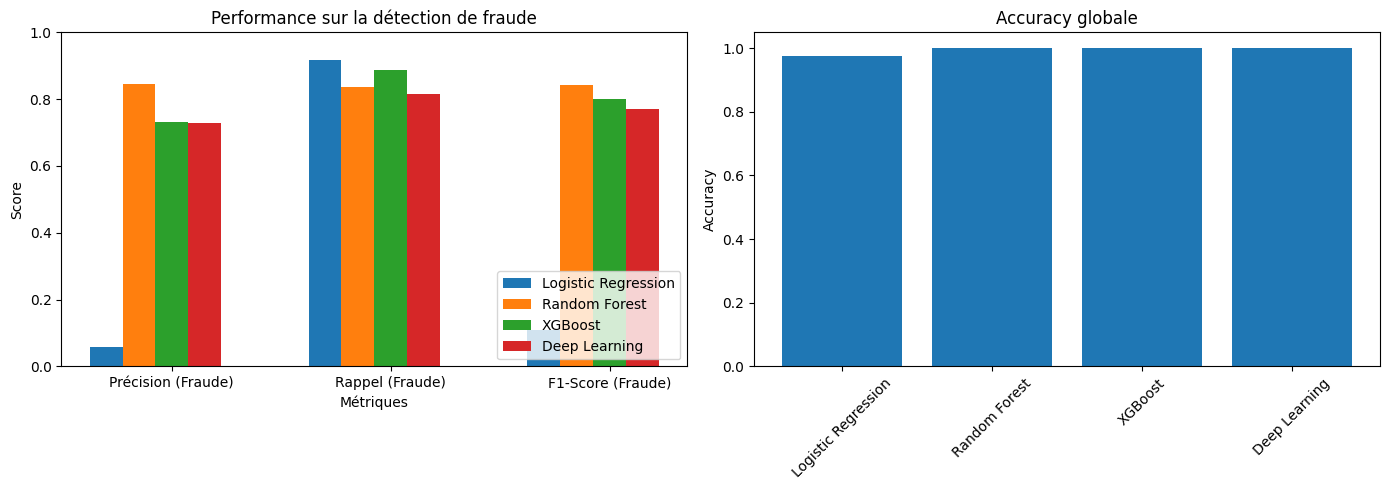

In [11]:
# @title 10. Comparaison ML vs DL
print("="*50)
print("COMPARAISON ML VS DEEP LEARNING")
print("="*50)

# Collecte des métriques pour comparaison
comparison_data = []

# Métriques ML
for name in ml_models.keys():
    report = classification_report(y_test, ml_predictions[name], output_dict=True)
    comparison_data.append({
        'Modèle': name,
        'Type': 'Machine Learning',
        'Précision (Fraude)': report['1']['precision'],
        'Rappel (Fraude)': report['1']['recall'],
        'F1-Score (Fraude)': report['1']['f1-score'],
        'Accuracy': report['accuracy']
    })

# Métriques DL
report_dl = classification_report(y_test, y_pred_dl, output_dict=True)
comparison_data.append({
    'Modèle': 'Deep Learning',
    'Type': 'Deep Learning',
    'Précision (Fraude)': report_dl['1']['precision'],
    'Rappel (Fraude)': report_dl['1']['recall'],
    'F1-Score (Fraude)': report_dl['1']['f1-score'],
    'Accuracy': report_dl['accuracy']
})

# DataFrame de comparaison
comparison_df = pd.DataFrame(comparison_data)
print("\nTableau comparatif:")
print(comparison_df.to_string(index=False))

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison des métriques pour la classe frauduleuse
metrics = ['Précision (Fraude)', 'Rappel (Fraude)', 'F1-Score (Fraude)']
x = np.arange(len(metrics))
width = 0.15

for i, (idx, row) in enumerate(comparison_df.iterrows()):
    axes[0].bar(x + i*width, [row[m] for m in metrics], width, label=row['Modèle'])

axes[0].set_xlabel('Métriques')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance sur la détection de fraude')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics)
axes[0].legend(loc='lower right')
axes[0].set_ylim([0, 1])

# Accuracy
axes[1].bar(comparison_df['Modèle'], comparison_df['Accuracy'])
axes[1].set_title('Accuracy globale')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Partie 7 : Interface Gradio

In [12]:
# @title 11. Création de l'interface Gradio
print("="*50)
print("CRÉATION DE L'INTERFACE GRADIO")
print("="*50)

def predict_fraud_ml(time, amount, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10,
                     v11, v12, v13, v14, v15, v16, v17, v18, v19, v20,
                     v21, v22, v23, v24, v25, v26, v27, v28):
    # Création du vecteur de features
    features = [time, amount, v1, v2, v3, v4, v5, v6, v7, v8, v9, v10,
                v11, v12, v13, v14, v15, v16, v17, v18, v19, v20,
                v21, v22, v23, v24, v25, v26, v27, v28]
    
    # Normalisation
    features_scaled = features.copy()
    features_scaled[0] = (features[0] - scaler.mean_[0]) / scaler.scale_[0]  # Time
    features_scaled[1] = (features[1] - scaler.mean_[1]) / scaler.scale_[1]  # Amount
    
    features_array = np.array(features_scaled).reshape(1, -1)
    
    # Prédictions
    results = {}
    
    # ML - Random Forest (meilleur modèle ML)
    rf_pred = ml_models['Random Forest'].predict_proba(features_array)[0][1]
    results['Random Forest'] = float(rf_pred)
    
    # ML - XGBoost
    xgb_pred = ml_models['XGBoost'].predict_proba(features_array)[0][1]
    results['XGBoost'] = float(xgb_pred)
    
    # Deep Learning
    dl_pred = float(dl_model.predict(features_array, verbose=0)[0][0])
    results['Deep Learning'] = dl_pred
    
    # Prédiction moyenne
    avg_pred = np.mean(list(results.values()))
    results['Moyenne'] = float(avg_pred)
    
    # Détermination de la décision finale
    decision = "FRAUDE DÉTECTÉE" if avg_pred > 0.5 else "Transaction normale"
    
    return results, decision

# Création des inputs Gradio
inputs = []
inputs.append(gr.Number(label="Time (secondes depuis première transaction)"))
inputs.append(gr.Number(label="Amount (montant en €)"))

for i in range(1, 29):
    inputs.append(gr.Number(label=f"V{i}", value=0.0))

# Création des outputs
outputs = [
    gr.JSON(label="Probabilités de fraude par modèle"),
    gr.Textbox(label="Décision finale")
]

# Création de l'interface
interface = gr.Interface(
    fn=predict_fraud_ml,
    inputs=inputs,
    outputs=outputs,
    title="Détection de Fraude Bancaire - ML vs Deep Learning",
    description="""Comparez les prédictions de différents modèles pour détecter une transaction frauduleuse.
    Les features V1 à V28 sont issues d'une ACP (anonymisées).""",
    examples=[
        [0, 100.0] + [0.0]*28,  # Exemple normal
        [50000, 2000.0] + [2.5]*28,  # Exemple suspect
    ],
    theme="soft"
)

print("Interface Gradio créée avec succès!")

CRÉATION DE L'INTERFACE GRADIO
Interface Gradio créée avec succès!


In [13]:
# @title 12. Lancement de l'application
print("="*50)
print("LANCEMENT DE L'APPLICATION GRADIO")
print("="*50)
print("Cliquez sur le lien ci-dessous pour ouvrir l'interface:")
interface.launch(share=True, debug=False)

LANCEMENT DE L'APPLICATION GRADIO
Cliquez sur le lien ci-dessous pour ouvrir l'interface:
* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
